In [59]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [60]:
BATCH_SIZE = 256
EPOCHS = 20
LEARNING_RATE = 0.001
TRAIN_DIR = "cifar3/train"
TEST_DIR = "cifar3/test"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print("Устройство:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

Устройство: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
CUDA: 12.1


In [61]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [62]:
class MyCifarDataset(ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root=root, transform=transform)

    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        return image, label

In [63]:
train_dataset = MyCifarDataset(
    root=TRAIN_DIR,
    transform=train_transform
)

test_dataset = MyCifarDataset(
    root=TEST_DIR,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)
print("Классы:", train_dataset.classes)
print("Тренировочные изображения:", len(train_dataset))
print("Тестовые изображения:", len(test_dataset))

Классы: ['apple', 'bus', 'dolphin']
Тренировочные изображения: 1500
Тестовые изображения: 300


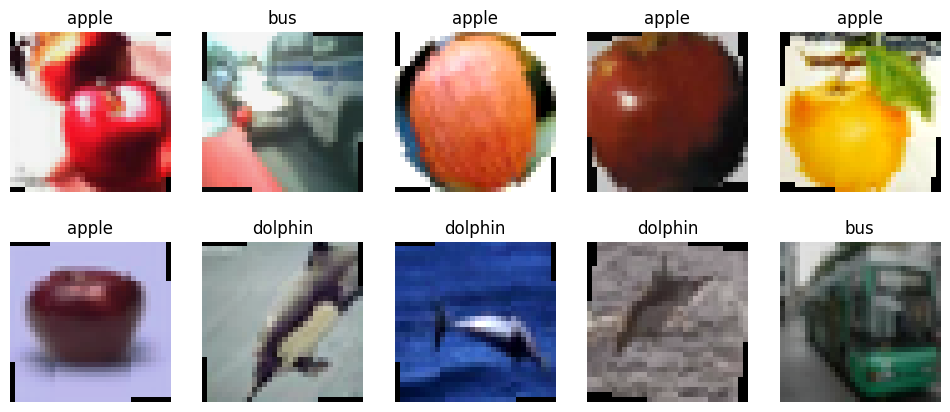

In [64]:
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    img = images[i]
    img = img / 2 + 0.5
    np_img = img.permute(1, 2, 0).numpy()
    ax.imshow(np_img)
    ax.set_title(train_dataset.classes[labels[i]])
    ax.axis("off")

plt.show()

In [65]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 3)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [66]:
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.

In [67]:
train_losses = []
train_accuracies = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    loop = tqdm(train_loader)
    for images, labels in loop:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        loop.set_description(f"Эпоха {epoch+1}/{EPOCHS}")
        loop.set_postfix(
            loss=loss.item(),
            accuracy=100 * correct / total
        )

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)
    print(
        f"Эпоха {epoch+1}: "
        f"Функция потерь = {epoch_loss:.4f}, "
        f"Точность = {epoch_accuracy:.2f}%"
    )

Эпоха 1/20: 100%|██████████| 6/6 [00:01<00:00,  3.96it/s, accuracy=62.4, loss=0.473]


Эпоха 1: Функция потерь = 0.7799, Точность = 62.40%


Эпоха 2/20: 100%|██████████| 6/6 [00:01<00:00,  4.46it/s, accuracy=87.3, loss=0.276]


Эпоха 2: Функция потерь = 0.3433, Точность = 87.33%


Эпоха 3/20: 100%|██████████| 6/6 [00:01<00:00,  4.42it/s, accuracy=89.7, loss=0.21] 


...

Эпоха 18: Функция потерь = 0.0691, Точность = 97.40%


Эпоха 19/20: 100%|██████████| 6/6 [00:03<00:00,  1.81it/s, accuracy=97.7, loss=0.0488]


Эпоха 19: Функция потерь = 0.0646, Точность = 97.67%


Эпоха 20/20: 100%|██████████| 6/6 [00:03<00:00,  1.74it/s, accuracy=98.7, loss=0.0175]

Эпоха 20: Функция потерь = 0.0419, Точность = 98.73%


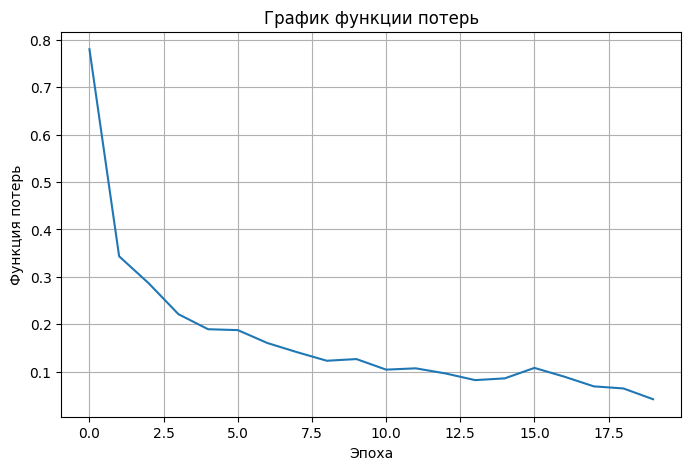

In [68]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses)
plt.title("График функции потерь")
plt.xlabel("Эпоха")
plt.ylabel("Функция потерь")
plt.grid()
plt.show()

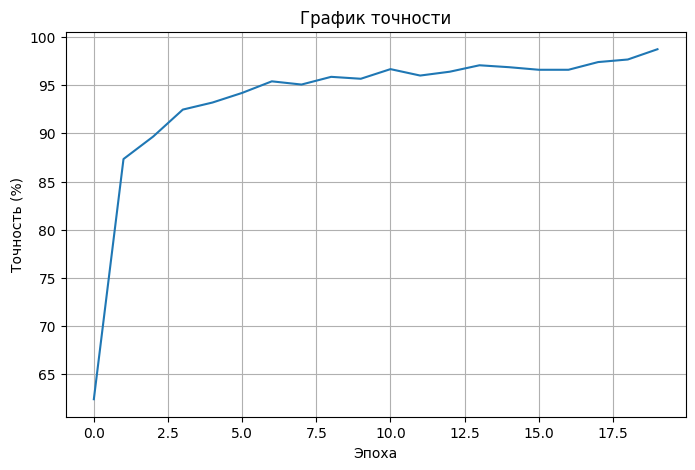

In [69]:
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies)
plt.title("График точности")
plt.xlabel("Эпоха")
plt.ylabel("Точность (%)")
plt.grid()
plt.show()

In [70]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"Точность на тестовой выборке: {test_accuracy:.2f}%")

Точность на тестовой выборке:: 97.67%


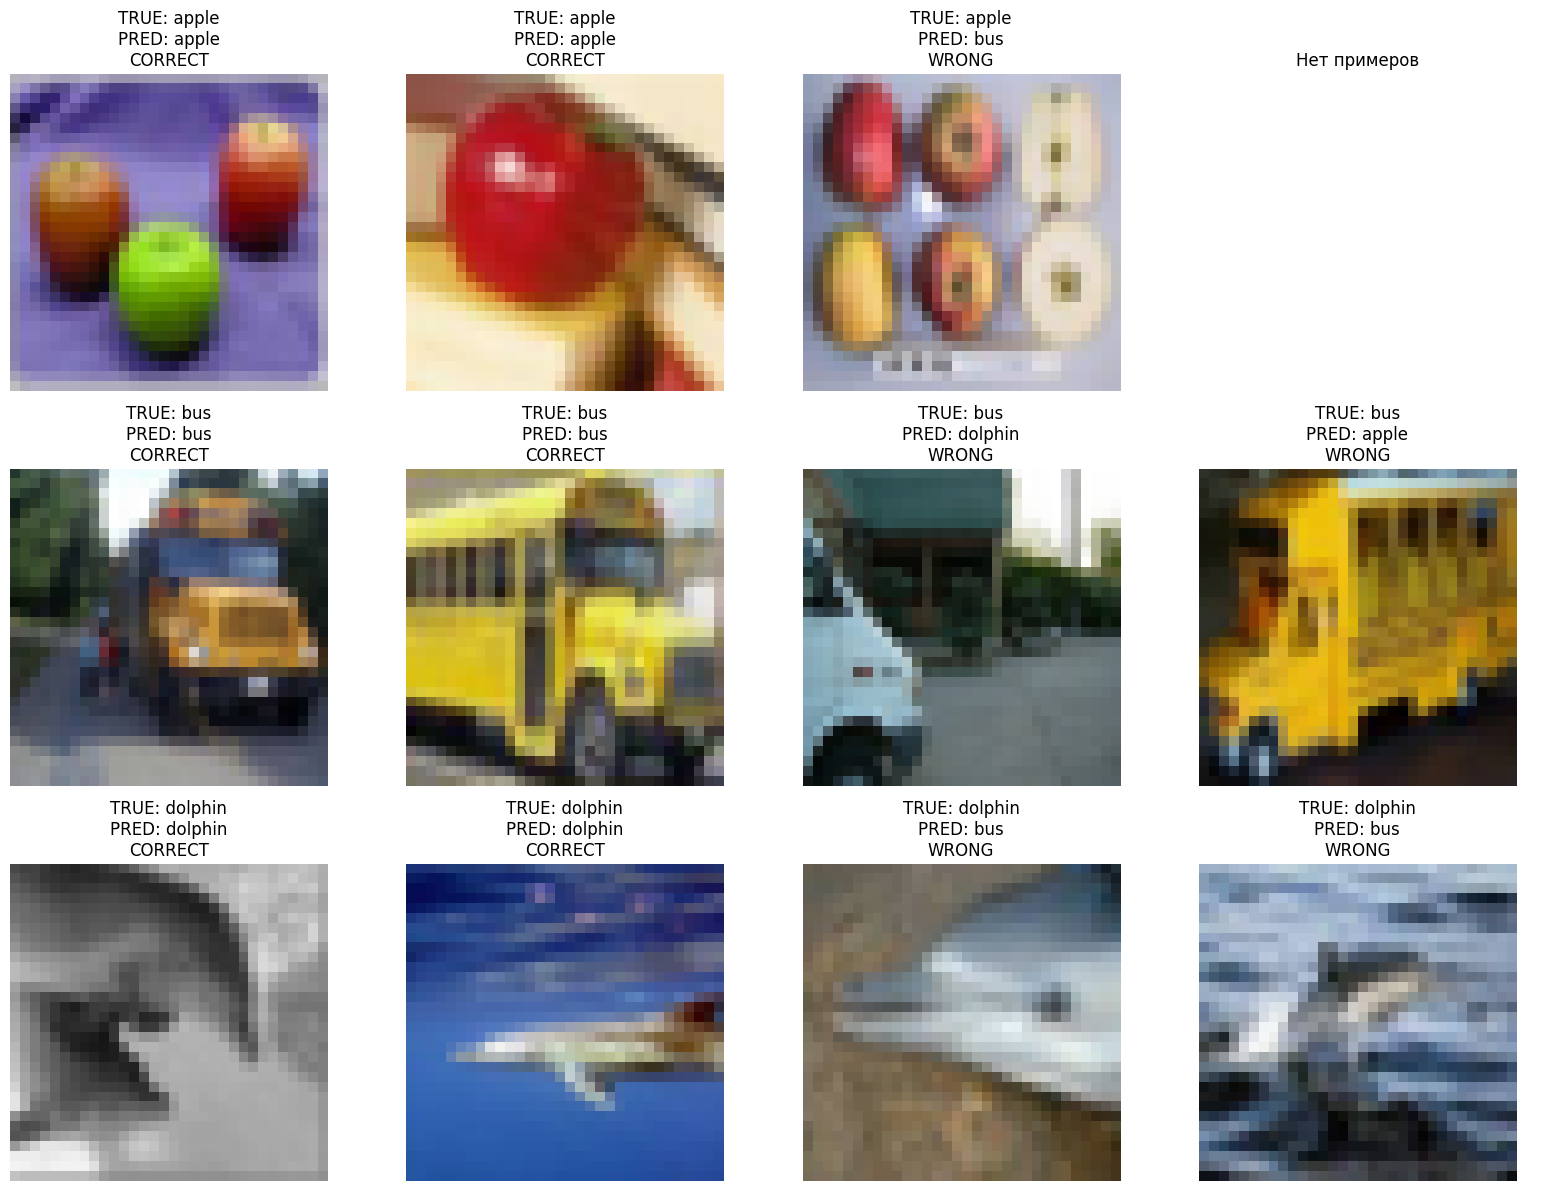

In [71]:
model.eval()
class_names = train_dataset.classes
results = {
    class_name: {
        "correct": [],
        "wrong": []
    }
    for class_name in class_names
}


with torch.no_grad():
    for images, labels in test_loader:
        images_gpu = images.to(device)
        outputs = model(images_gpu)
        _, predicted = torch.max(outputs, 1)
        for i in range(len(labels)):
            true_idx = labels[i].item()
            pred_idx = predicted[i].item()
            true_class = class_names[true_idx]
            pred_class = class_names[pred_idx]
            image = images[i]
            if true_idx == pred_idx:
                if len(results[true_class]["correct"]) < 2:
                    results[true_class]["correct"].append((image, pred_class))
            else:
                if len(results[true_class]["wrong"]) < 2:
                    results[true_class]["wrong"].append((image, pred_class))

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for row, class_name in enumerate(class_names):
    examples = (
        results[class_name]["correct"] +
        results[class_name]["wrong"]
    )
    for col in range(4):
        ax = axes[row, col]
        if col < len(examples):
            img, pred_class = examples[col]
            img = img / 2 + 0.5
            np_img = img.permute(1, 2, 0).numpy()
            ax.imshow(np_img)
            is_correct = (
                pred_class == class_name
            )
            status = (
                "CORRECT"
                if is_correct
                else "WRONG"
            )
            ax.set_title(
                f"TRUE: {class_name}\n"
                f"PRED: {pred_class}\n"
                f"{status}"
            )
        else:
            ax.set_title("Нет примеров")
        ax.axis("off")

plt.tight_layout()
plt.show()